# Random Forest Classification

#### 1. Import Required Libraries

In [1]:
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

import joblib


#### 2. Load the precomputed dataset


In [2]:
files = glob.glob(r"Z:\Bundesliga_23_24\aug_data_window_global.csv")
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

In [3]:
df.columns

Index(['match_id', 'match_title', 'team_code', 'home_team_code',
       'away_team_code', 'player_name', 'game_section', 'x_norm_mean',
       'y_norm_mean', 'x_norm_std', 'y_norm_std', 'speed_mean', 'window',
       'dominant_possession', 'window_start_sec', 'window_end_sec',
       'window_duration_sec', 'dominant_possession_team', 'formation',
       'window_global'],
      dtype='object')

In [4]:
df.value_counts("formation")//10 #10 players per window

formation
5-3-2        286
4-2-3-1      273
4-4-2        250
3-1-4-2      224
4-3-3        210
3-4-2-1      190
5-2-3        180
remove       119
3-1-5-1       98
4-2-2-2       86
4-D-2         84
3-4-1-2       82
5-4-1         78
5-2-1-2       64
4-1-4-1       46
3-4-3         40
4-1-3-2       30
5-3-1-1       20
5-1-3-1       10
4-5-1          4
4-1-2-1-2      2
3-5-2          2
Name: count, dtype: int64

In [5]:
# Remove underrepresented classes
min_samples = 30*10  # Minimum 30 windows (10 players per window)
counts = df["formation"].value_counts()
valid_classes = counts[counts >= min_samples].index
df = df[df["formation"].isin(valid_classes)].reset_index(drop=True)

# Drop formations marked as 'remove'
df = df[df["formation"] != 'remove'].reset_index(drop=True)

#### 3. Feature Re-computation per Window

In [6]:
def compute_team_features(group):
    x = group["x_norm_mean"].values
    y = group["y_norm_mean"].values
    
    centroid_x = np.mean(x)
    centroid_y = np.mean(y)
    width = x.max() - x.min()
    length = y.max() - y.min()
    distances = np.sqrt((x - centroid_x)**2 + (y - centroid_y)**2)
    dist_mean = np.mean(distances)
    dist_std = np.std(distances)
    
    return pd.Series({
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "width": width,
        "length": length,
        "dist_mean": dist_mean,
        "dist_std": dist_std
    })

team_features = df.groupby("window_global").apply(compute_team_features).reset_index()
df = df.merge(team_features, on="window_global", how="left")

C:\Users\erraf\AppData\Local\Temp\ipykernel_13224\3089133545.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_features = df.groupby("window_global").apply(compute_team_features).reset_index()


#### 4. Define Features and Target

In [7]:
target_col = "formation"
y = df[target_col].astype("category")

# Numeric features (spatial + motion)
num_cols = [
    "x_norm_mean", "y_norm_mean", "x_norm_std", "y_norm_std", "speed_mean",
    "dominant_possession", "centroid_x", "centroid_y",
    "width", "length", "dist_mean", "dist_std"
]

# Categorical features
cat_cols = ["game_section", "dominant_possession_team"]

#### 5. Split Data (Avoid Leakage Between Windows)

In [8]:
groups = df["window_global"].values  # each tactical window = one group
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Train samples: 17760, Test samples: 4450


#### 6. Define preprocessing and Random Forest Model

In [9]:
# Numeric: impute missing values
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

# Categorical: impute + OneHotEncode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric & categorical preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

In [10]:
# Random Forest classifier
clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight=None,
    max_features=0.3,
    min_samples_split=16,
    min_samples_leaf=4,
    n_jobs=-1
)

# Full pipeline
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", clf)
])

#### 7. Train model

In [11]:
pipe.fit(train_df[num_cols + cat_cols], y_train := train_df[target_col])


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['x_norm_mean', 'y_norm_mean',
                                                   'x_norm_std', 'y_norm_std',
                                                   'speed_mean',
                                                   'dominant_possession',
                                                   'centroid_x', 'centroid_y',
                                                   'width', 'length',
                                                   'dist_mean', 'dist_std']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['game_section',
                                                   'dominant_possession_team'])])),
                ('model',
                 RandomForestClassifier(max_features=0.3, min_samples_leaf=4,
                                        min_samples_split=16, n_estimators=800,
                                        n_jobs=-1, random_state=42))])

#### 8. Evaluate Model

In [12]:
y_test = test_df[target_col]
y_pred = pipe.predict(test_df[num_cols + cat_cols])

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7914606741573034
              precision    recall  f1-score   support

     3-1-4-2       0.81      0.76      0.79       490
     3-1-5-1       0.81      1.00      0.89       200
     3-4-1-2       0.83      0.69      0.75       130
     3-4-2-1       0.77      0.85      0.81       400
       3-4-3       0.80      0.80      0.80       100
     4-1-3-2       0.71      0.71      0.71        70
     4-1-4-1       0.86      1.00      0.92       120
     4-2-2-2       1.00      0.78      0.88       180
     4-2-3-1       0.59      0.33      0.43       620
       4-3-3       0.74      0.94      0.83       340
       4-4-2       0.71      0.91      0.80       370
       4-D-2       0.84      0.85      0.84       130
     5-2-1-2       1.00      0.80      0.89       100
       5-2-3       0.92      0.80      0.86       390
       5-3-2       0.78      1.00      0.88       630
       5-4-1       0.98      0.75      0.85       180

    accuracy                           0.79      44

#### 9. Feature Importance Extraction

In [13]:
try:
    # Extract OHE feature names
    ohe = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
    all_feature_names = num_cols + cat_feature_names

    importances = pipe.named_steps["model"].feature_importances_

    if len(importances) == len(all_feature_names):
        feat_imp = pd.DataFrame({
            "feature": all_feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        print("\nTop 20 Feature Importances:")
        print(feat_imp.head(20).to_string(index=False))
    else:
        print("\n[Note] Feature count mismatch after OHE — skipping feature importance output.")
except Exception as e:
    print("\n[Warning] Could not extract feature importances:", e)



Top 20 Feature Importances:
                                   feature  importance
                                    length    0.158223
                                 dist_mean    0.152187
                                centroid_x    0.149734
                                     width    0.148530
                                  dist_std    0.145922
                                centroid_y    0.060808
    dominant_possession_team_In_possession    0.035256
dominant_possession_team_Out_of_possession    0.033759
                       dominant_possession    0.028300
                    game_section_firstHalf    0.018622
                   game_section_secondHalf    0.018592
                                speed_mean    0.018222
                                x_norm_std    0.013353
                                y_norm_std    0.013020
                               x_norm_mean    0.003736
                               y_norm_mean    0.001736


In [14]:
# ========= 10) Learning Curves (group-aware) =========
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, learning_curve
import matplotlib.pyplot as plt



cv = GroupKFold(n_splits=5)

train_sizes = np.linspace(0.1, 1.0, 8)

# Ensure X_cols is defined (use existing num_cols + cat_cols if needed)
try:
    X_cols
except NameError:
    X_cols = num_cols + cat_cols

ts, tr_acc, te_acc = learning_curve(
    pipe, df[X_cols], y, groups=groups,
    cv=cv, scoring="accuracy", n_jobs=-1,
    train_sizes=train_sizes, shuffle=True, random_state=42
)

_, tr_f1, te_f1 = learning_curve(
    pipe, df[X_cols], y, groups=groups,
    cv=cv, scoring="f1_macro", n_jobs=-1,
    train_sizes=train_sizes, shuffle=True, random_state=42
)

def mean_std(a): return a.mean(axis=1), a.std(axis=1)
tr_acc_m, tr_acc_s = mean_std(tr_acc)
te_acc_m, te_acc_s = mean_std(te_acc)
tr_f1_m,  tr_f1_s  = mean_std(tr_f1)
te_f1_m,  te_f1_s  = mean_std(te_f1)

plt.figure(figsize=(9,5))
plt.plot(ts, tr_acc_m, "o-", label="Train Accuracy")
plt.fill_between(ts, tr_acc_m - tr_acc_s, tr_acc_m + tr_acc_s, alpha=0.15)
plt.plot(ts, te_acc_m, "o--", label="Test Accuracy")
plt.fill_between(ts, te_acc_m - te_acc_s, te_acc_m + te_acc_s, alpha=0.15)
plt.plot(ts, tr_f1_m,  "s-", label="Train F1 (macro)")
plt.fill_between(ts, tr_f1_m - tr_f1_s, tr_f1_m + tr_f1_s, alpha=0.15)
plt.plot(ts, te_f1_m,  "s--", label="Test F1 (macro)")
plt.fill_between(ts, te_f1_m - te_f1_s, te_f1_m + te_f1_s, alpha=0.15)
plt.title("Learning Curves — Random Forest (group-aware)")
plt.xlabel("Training Set Size")
plt.ylabel("Score")
plt.grid(True, alpha=0.4, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

# Evaluation visualizations section

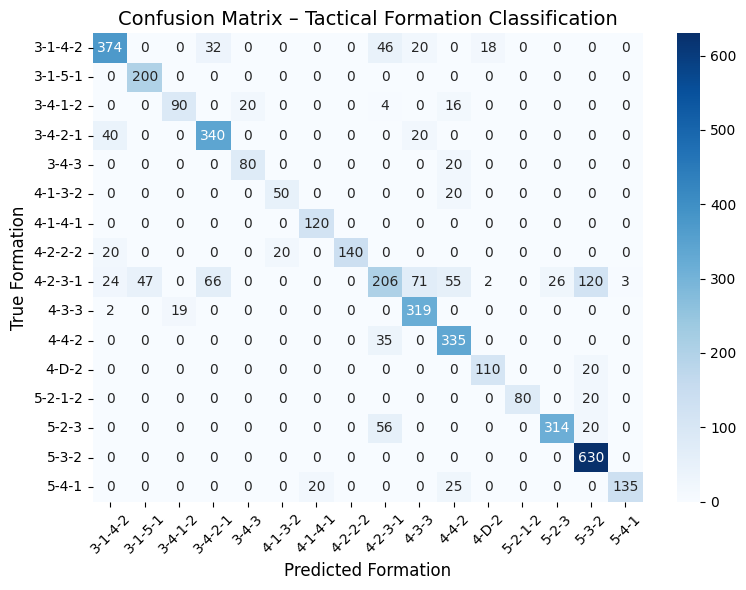

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
# Ensure categorical dtype for consistency
y_test = y_test.astype("category")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=y_test.cat.categories)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=y_test.cat.categories,
            yticklabels=y_test.cat.categories)
plt.title("Confusion Matrix – Tactical Formation Classification", fontsize=14)
plt.xlabel("Predicted Formation", fontsize=12)
plt.ylabel("True Formation", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#  Individual role classification for players defending corners in football (soccer)  Gabriel Anzer, Pascal Bauer*, and Joshua Wyatt Smith 

/tmp/ipykernel_1487579/955339564.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")


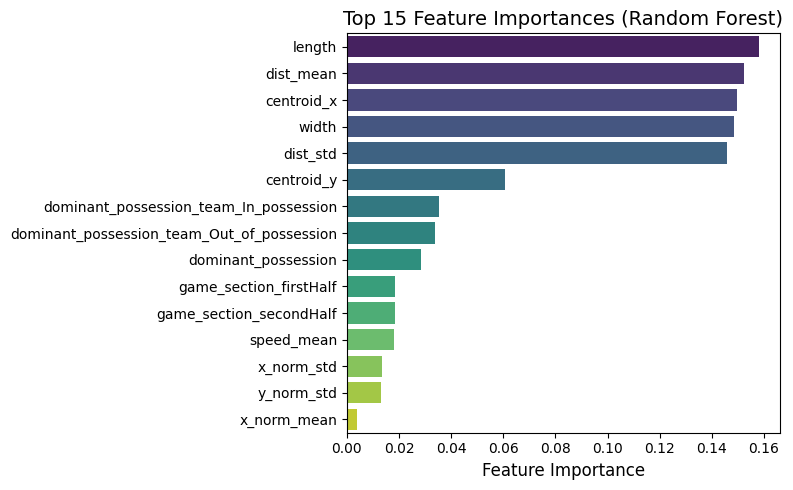

In [ ]:
# Feature Importance Plot
try:
    ohe = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
    all_feature_names = num_cols + cat_feature_names

    importances = pipe.named_steps["model"].feature_importances_

    if len(importances) == len(all_feature_names):
        feat_imp = pd.DataFrame({
            "feature": all_feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        plt.figure(figsize=(8,5))
        sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")
        plt.title("Top 15 Feature Importances (Random Forest)", fontsize=14)
        plt.xlabel("Feature Importance", fontsize=12)
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
    else:
        print("Feature count mismatch – skipping importance plot.")
except Exception as e:
    print(f"Could not extract feature importances: {e}")
    
    
# Gudmundsson & Horton, 2017 – Spatio-temporal analysis of team formations in football
# Decroos et al., 2019 – Actions Speak Louder Than Goals

#### 10. Save trained pipeline

In [16]:
import sklearn

bundle = {
    "pipe": pipe,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "sklearn_version": sklearn.__version__
}

joblib.dump(bundle, "rf_bundle.joblib")
print("\nSaved pipeline bundle: rf_bundle.joblib")
print("scikit-learn version:", sklearn.__version__)


Saved pipeline bundle: rf_bundle.joblib
scikit-learn version: 1.5.1


In [18]:
import sys
python_version = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
print("Python version:", python_version)

Python version: 3.12.9
